In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/YOLO/Multi-Class Urban Object Detection Using YOLO.zip"
extract_path = "/content/YOLO"

# Remove previous temporary copy
if os.path.exists(extract_path):
    import shutil
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [3]:
!find "/content/YOLO" -maxdepth 2 -type d

/content/YOLO
/content/YOLO/Multi-Class Urban Object Detection Using YOLO
/content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset
/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs


In [4]:
%cd "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

!pip install -q ultralytics

import ultralytics
import torch

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

/content/YOLO/Multi-Class Urban Object Detection Using YOLO
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.138
PyTorch: 2.11.0+cpu
CUDA Available: False


In [5]:
import os

print("===== PROJECT =====")
!pwd

print("\n===== PROJECT FILES =====")
!ls -lah

print("\n===== DATASET =====")

train_images = len([
    f for f in os.listdir("dataset/train/images")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

val_images = len([
    f for f in os.listdir("dataset/val/images")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Training images:", train_images)
print("Validation images:", val_images)

print("\n===== DATA YAML =====")
!cat data.yaml

===== PROJECT =====
/content/YOLO/Multi-Class Urban Object Detection Using YOLO

===== PROJECT FILES =====
total 6.3M
drwxr-xr-x 4 root root 4.0K Sep  2 09:04 .
drwxr-xr-x 3 root root 4.0K Sep  2 09:04 ..
-rw-r--r-- 1 root root 3.5K Sep  2 09:04 create_small_dataset.py
drwxr-xr-x 4 root root 4.0K Sep  2 09:04 dataset
-rw-r--r-- 1 root root  150 Sep  2 09:04 dataset.py
-rw-r--r-- 1 root root  194 Sep  2 09:04 data.yaml
drwxr-xr-x 3 root root 4.0K Sep  2 09:04 runs
-rw-r--r-- 1 root root 1.3K Sep  2 09:04 train.py
-rw-r--r-- 1 root root 6.3M Sep  2 09:04 yolov8n.pt

===== DATASET =====
Training images: 1500
Validation images: 375

===== DATA YAML =====
path: dataset

train: train/images
val: val/images

nc: 10

names:
  - person
  - rider
  - car
  - bus
  - truck
  - bike
  - motor
  - traffic light
  - traffic sign
  - train

In [ ]:
%cd "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

!python train.py

/content/YOLO/Multi-Class Urban Object Detection Using YOLO
       MULTI-CLASS URBAN OBJECT DETECTION USING YOLO

STARTING MODEL TRAINING
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

In [ ]:
import os
import glob

models = glob.glob(
    "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/"
    "runs/detect/**/weights/best.pt",
    recursive=True
)

print("Models found:")

for model in models:
    print(model)

Models found:
/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/runs/urban_object_detection_1000/weights/best.pt
/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/runs/urban_object_detection_1500/weights/best.pt


In [ ]:
from ultralytics import YOLO

MODEL = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/runs/urban_object_detection_1500/weights/best.pt"

model = YOLO(MODEL)

metrics = model.val(
    data="/content/YOLO/Multi-Class Urban Object Detection Using YOLO/data.yaml",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("\n" + "=" * 50)
print("FINAL VALIDATION RESULTS")
print("=" * 50)

print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2067.0±680.1 MB/s, size: 53.7 KB)
val: Scanning /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/labels.cache... 375 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 375/375 62.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.5it/s 5.3s
                   all        375       6829      0.485       0.24      0.259      0.148
                person        129        481        0.5      0.435      0.438      0.213
                 rider         19         23      0.603     0.0435     0.0995     0.0625
                   car        374       3744      0.619      0.593      0.608      0.359
                   bus         54         70      0.525        0.3      0.334      0.261

In [ ]:
from ultralytics import YOLO

MODEL = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/runs/urban_object_detection_1500/weights/best.pt"

model = YOLO(MODEL)

results = model.predict(
    source="/content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    save_conf=True
)

print("Prediction completed.")


image 1/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images/b1c66a42-6f7d68ca.jpg: 384x640 19 cars, 3 traffic signs, 5.6ms
image 2/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images/b1c81faa-3df17267.jpg: 384x640 1 car, 1 traffic light, 1 traffic sign, 6.2ms
image 3/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images/b1c81faa-c80764c5.jpg: 384x640 2 cars, 2 traffic signs, 6.6ms
image 4/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images/b1c9c847-3bda4659.jpg: 384x640 28 cars, 1 truck, 2 traffic signs, 5.6ms
image 5/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images/b1ca2e5d-84cf9134.jpg: 384x640 12 persons, 7 cars, 3 traffic lights, 5.8ms
image 6/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset/val/images/b1ca8418-84a133a0.jpg: 384x640 2 cars, 2 traffic lights, 4 traffic signs, 5.8ms
image 7/375 /content/YOL

Prediction images: 375
b20b69d2-ca16c907.jpg


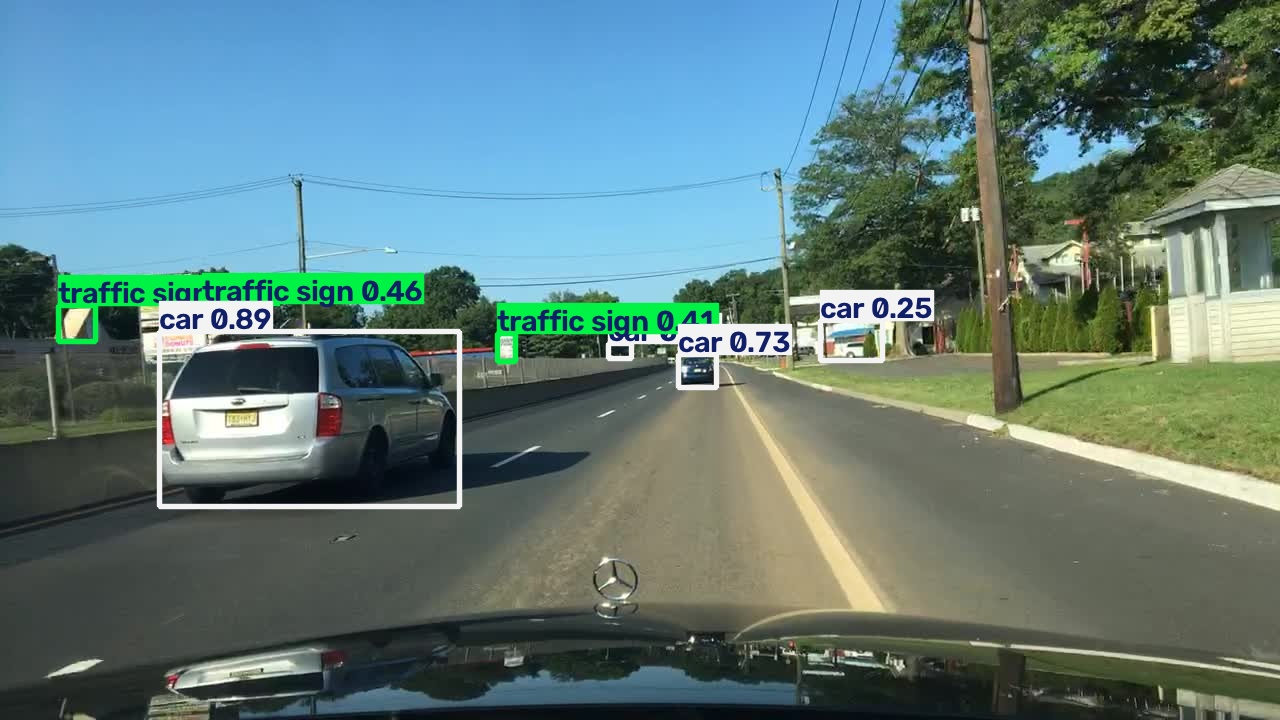

b1fbf878-b31a8293.jpg


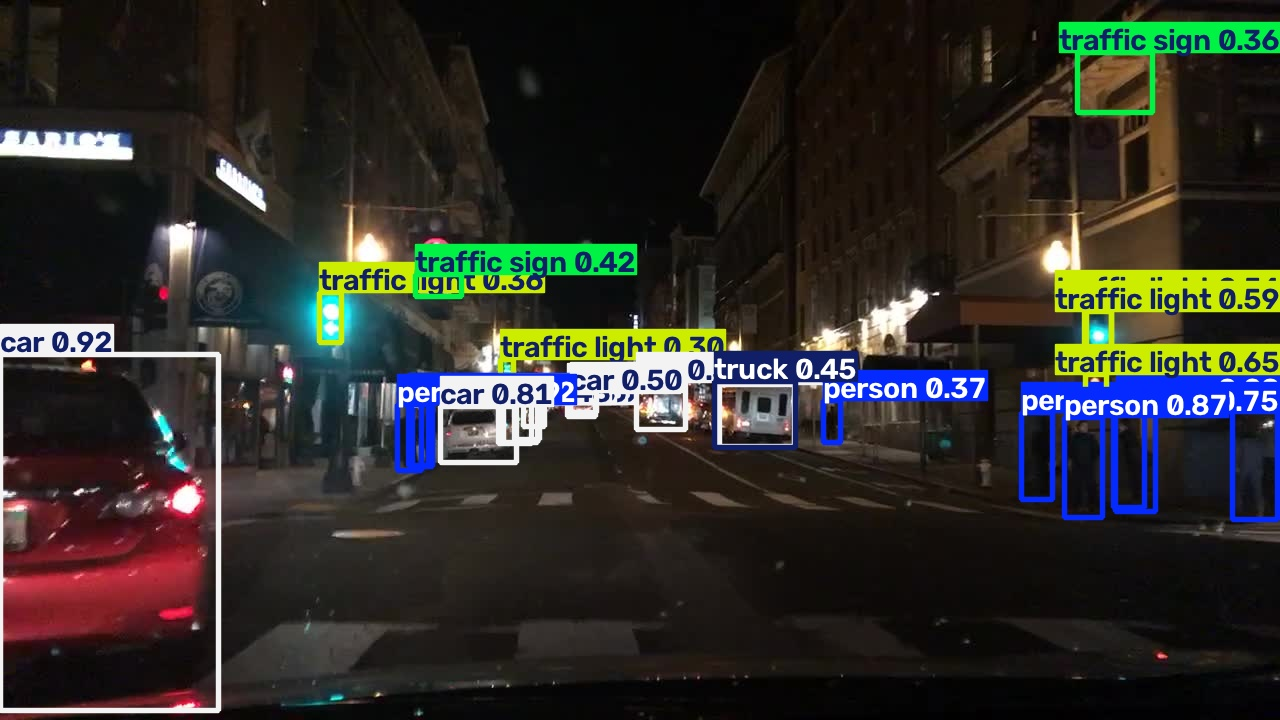

b214d1e1-f248c616.jpg


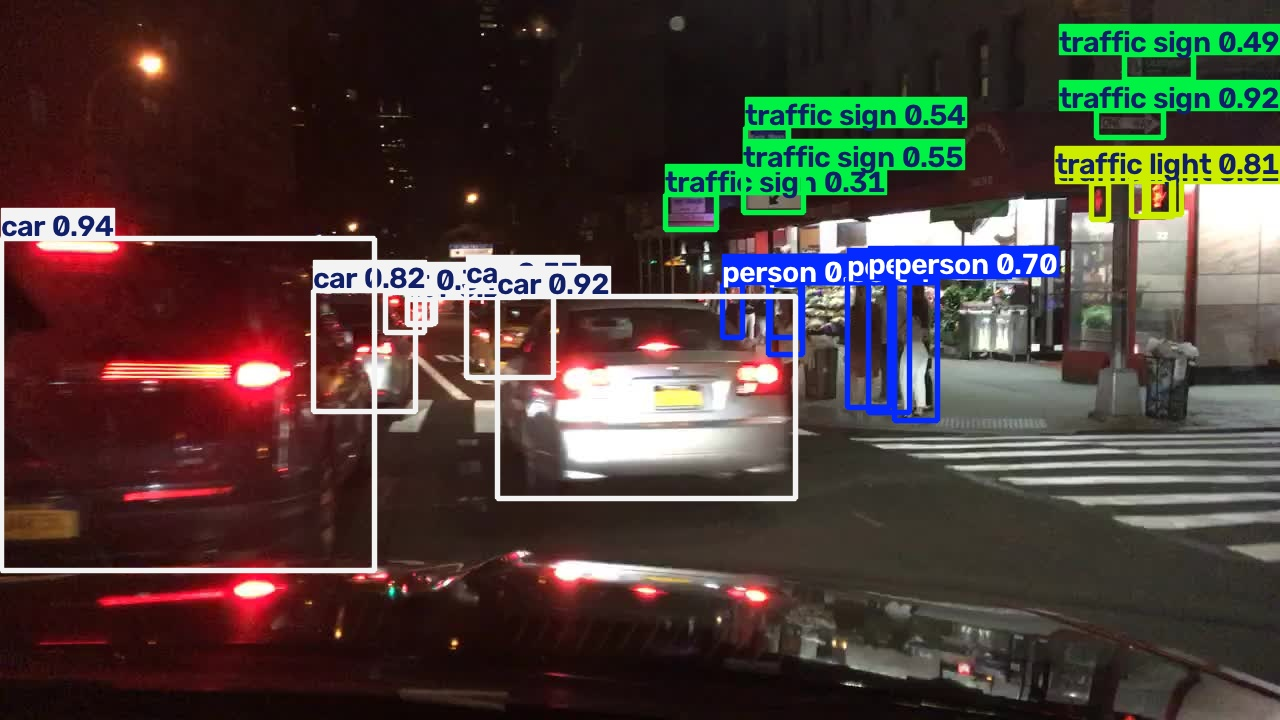

b1db7e22-cfa74dc3.jpg


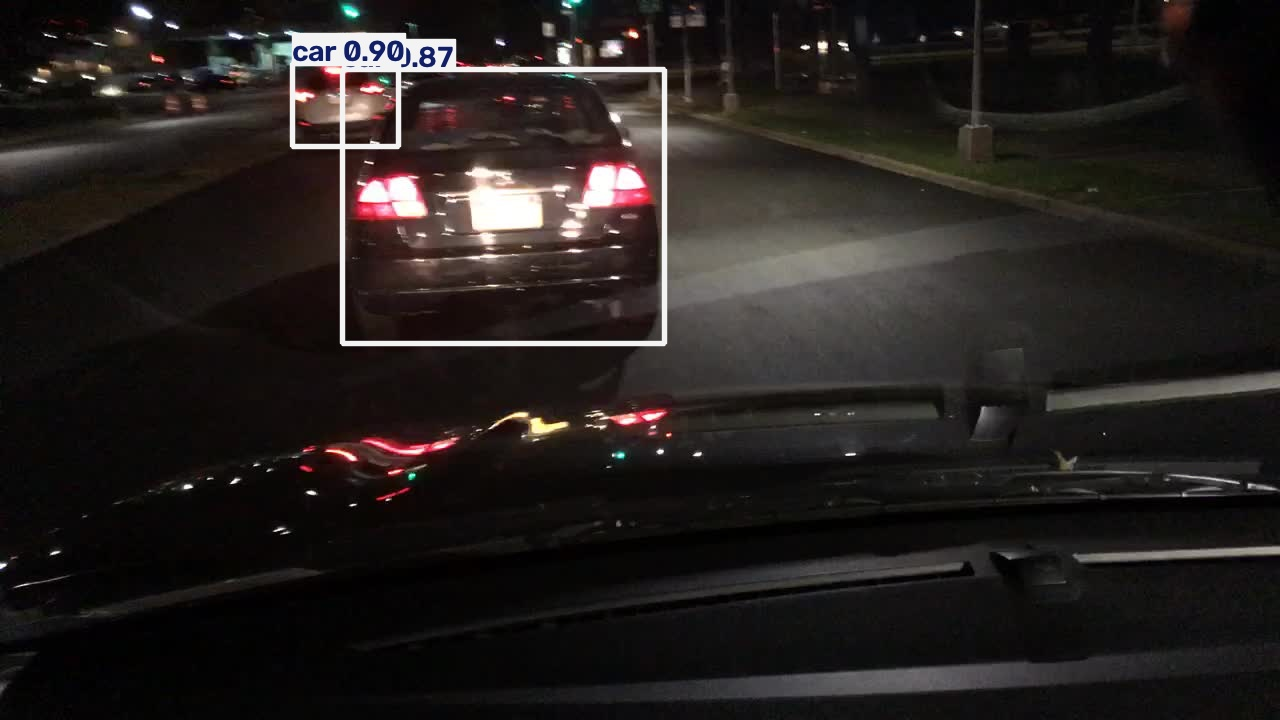

b1e1a7b8-0aec80e8.jpg


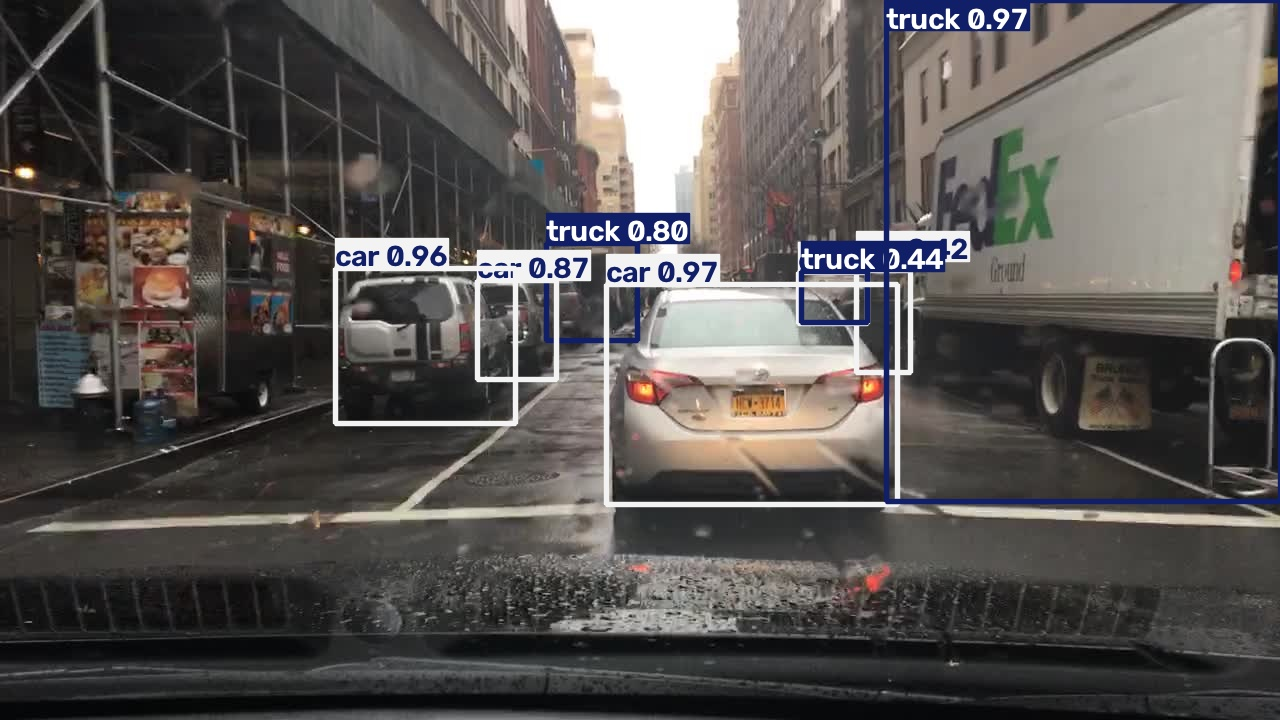

b2505382-272e7823.jpg


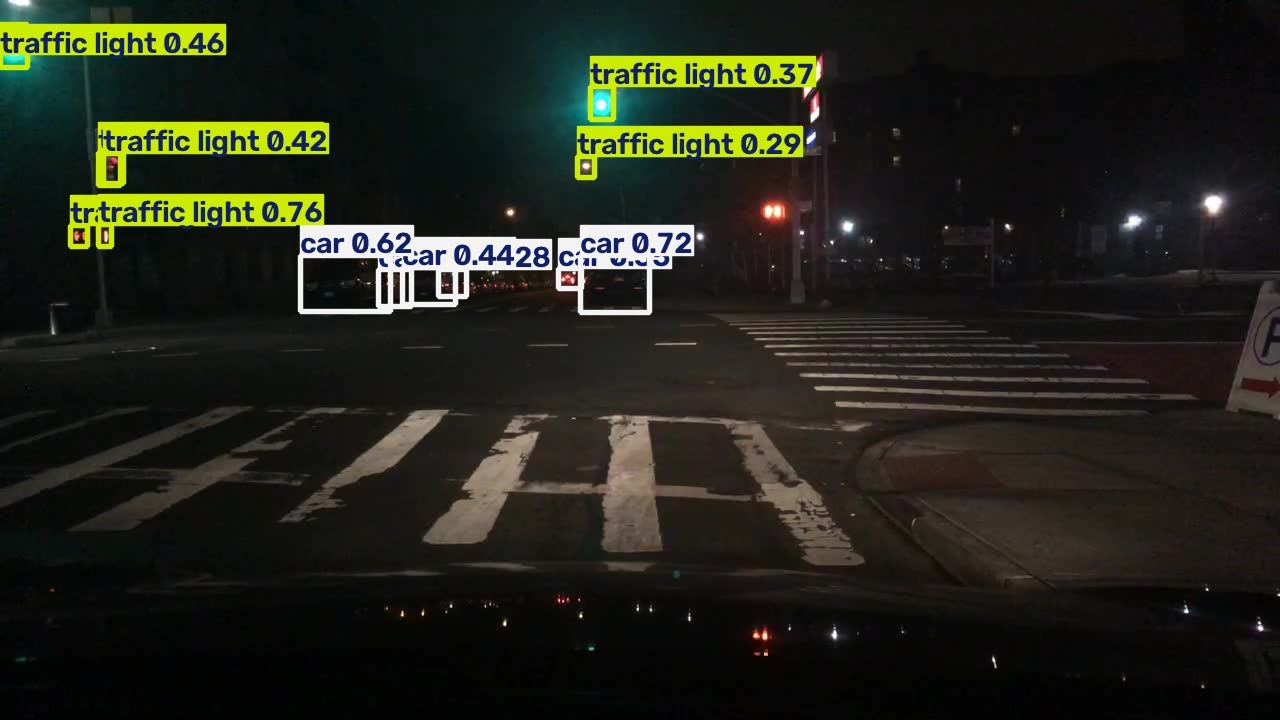

In [ ]:
from IPython.display import display, Image
import glob
import os

prediction_dir = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/predict"

images = glob.glob(os.path.join(prediction_dir, "*.jpg"))

print("Prediction images:", len(images))

# Display first 6 predictions
for img in images[:6]:
    print(os.path.basename(img))
    display(Image(filename=img, width=800))

b24b3585-221ac8ac.jpg


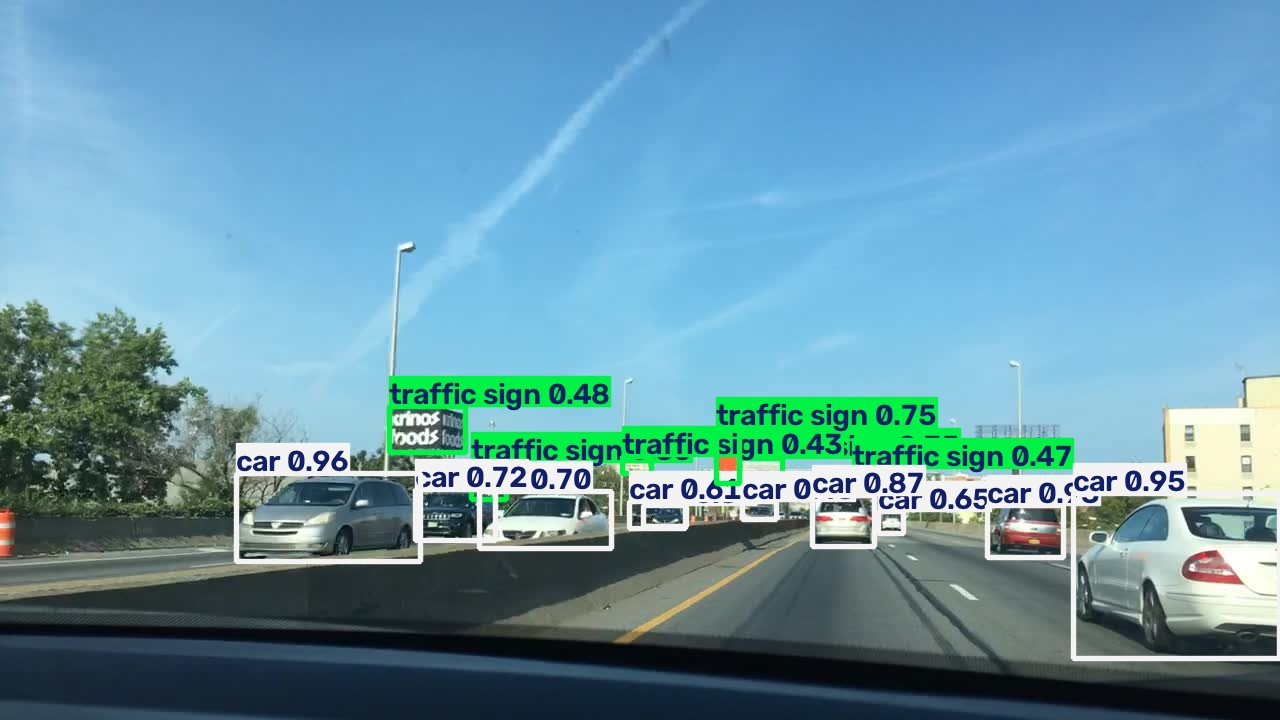

b25aac57-705d50ad.jpg


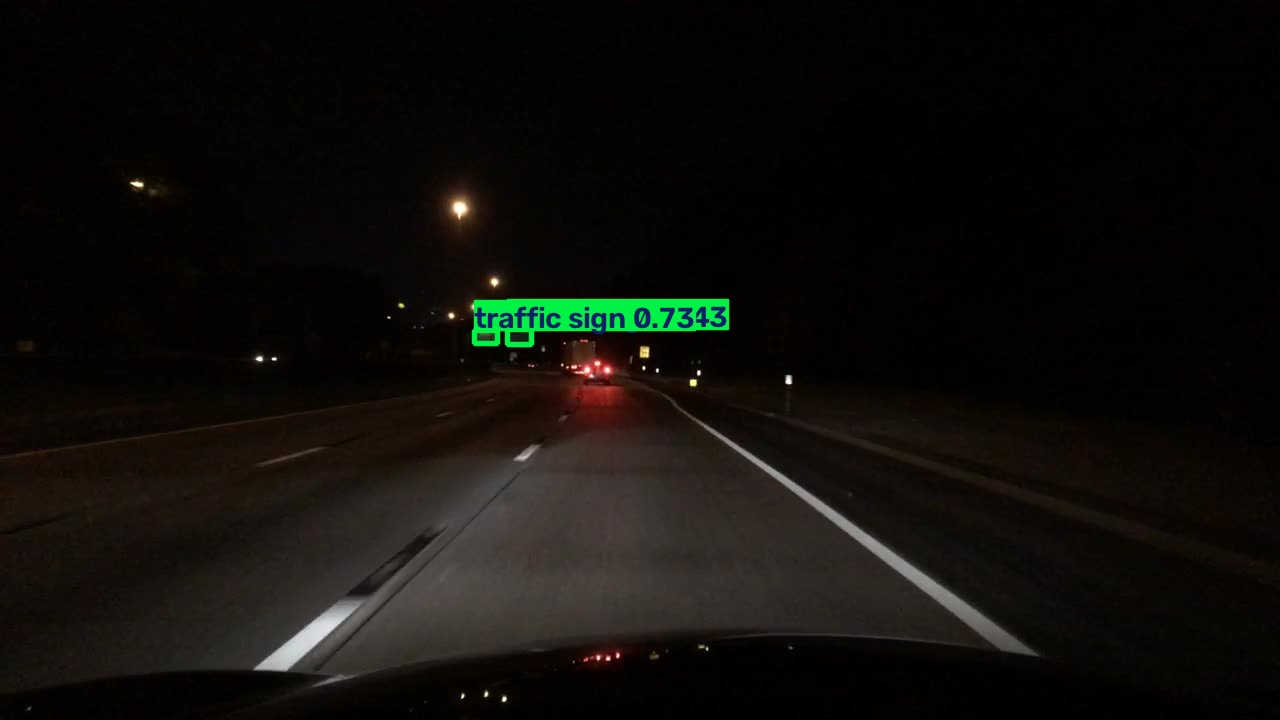

b24f7455-e8c55d6a.jpg


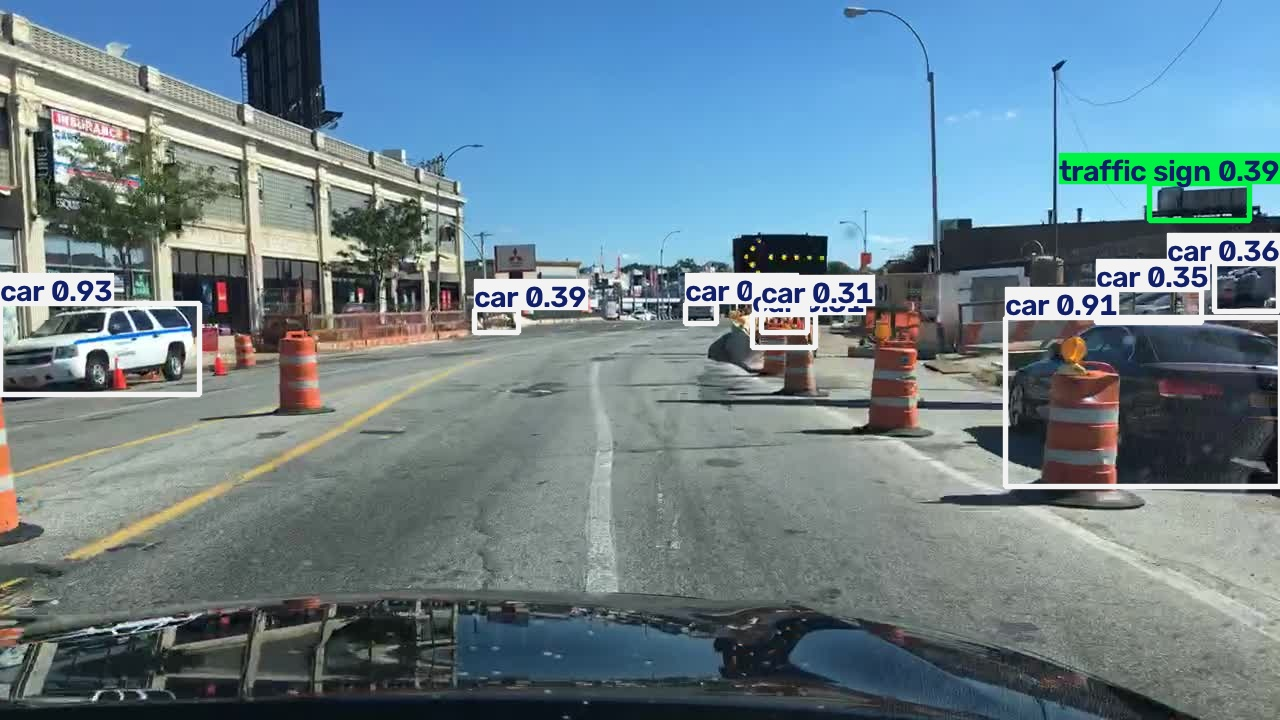

b277a772-715e949c.jpg


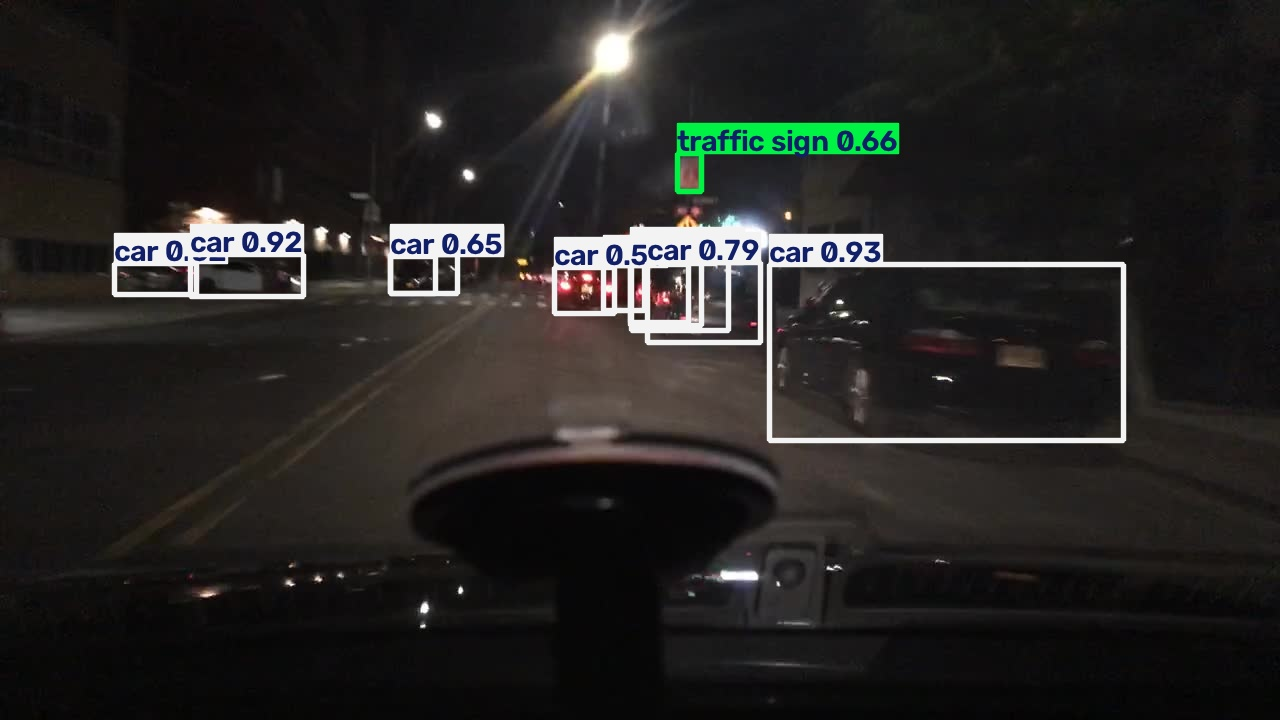

b25ae6c0-fb9fea6a.jpg


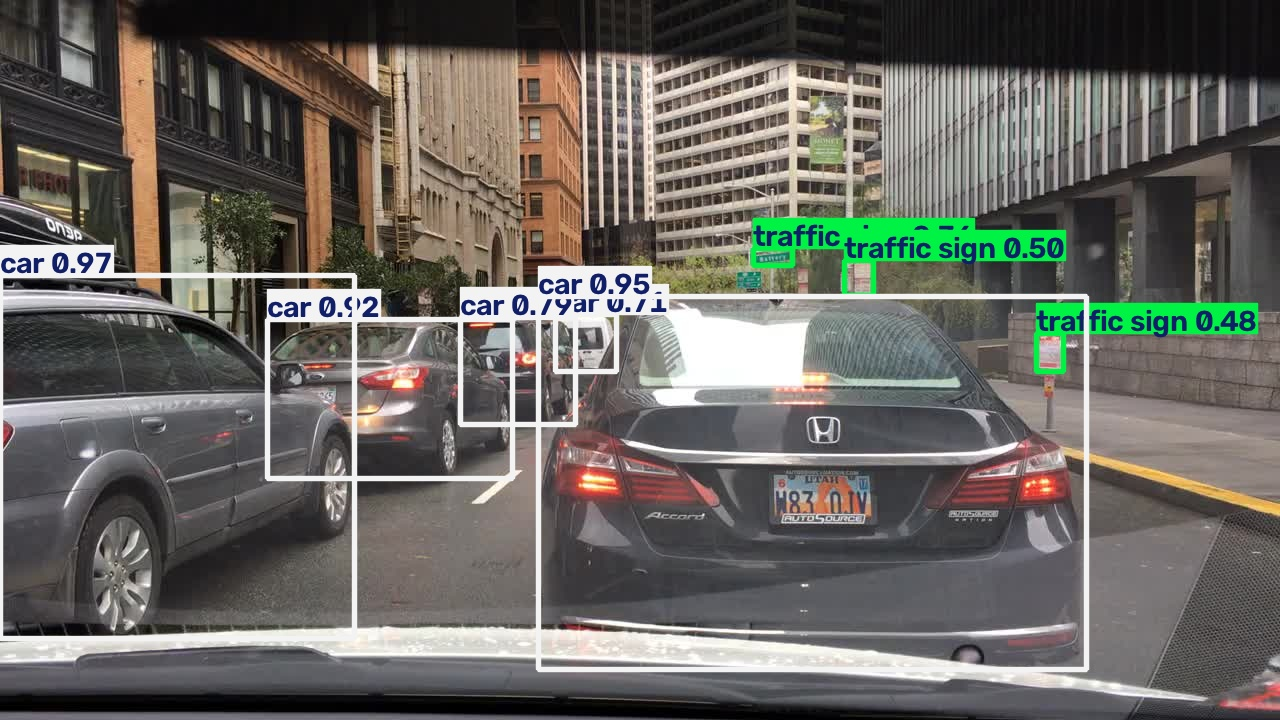

b1d9e136-9ab25cb3.jpg


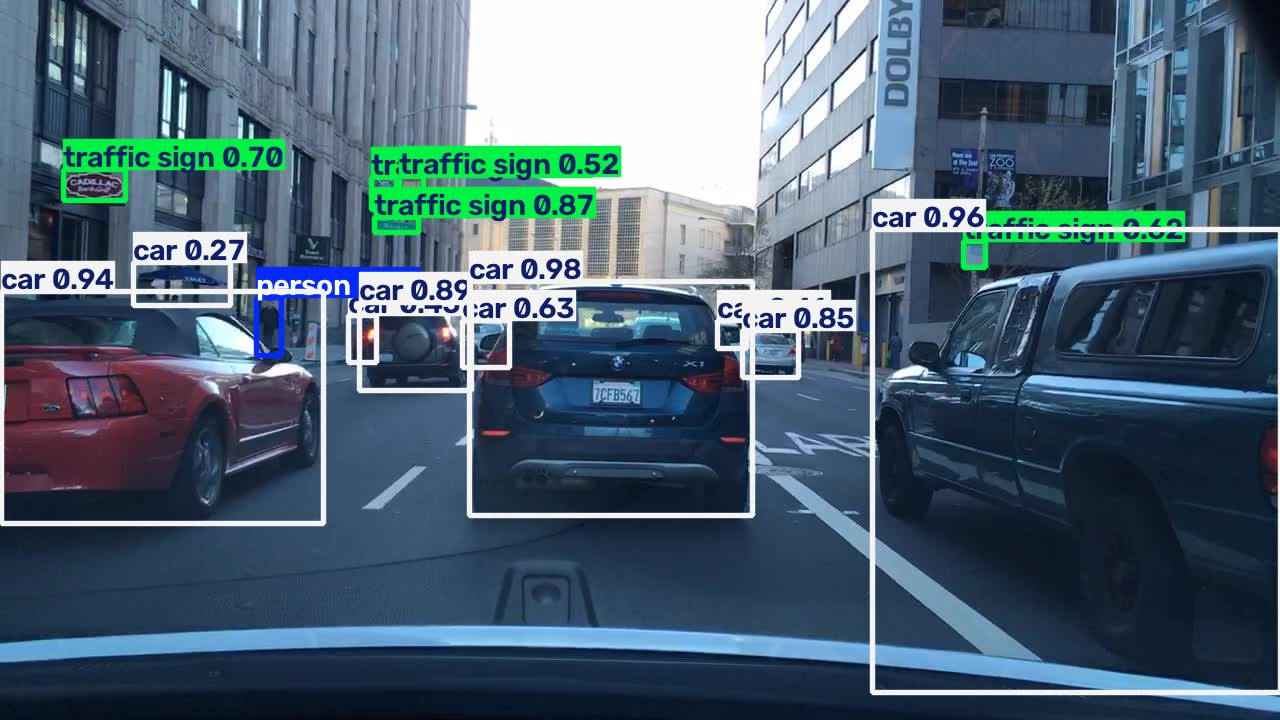

In [7]:
import os

BASE = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

print("BASE exists:", os.path.exists(BASE))
print("\nBASE contents:")

if os.path.exists(BASE):
    for x in os.listdir(BASE):
        print(" -", x)

BASE exists: True

BASE contents:
 - data.yaml
 - dataset
 - train.py
 - dataset.py
 - yolov8n.pt
 - runs
 - create_small_dataset.py
 - yolov8s.pt


In [8]:
from pathlib import Path

BASE = Path("/content/YOLO/Multi-Class Urban Object Detection Using YOLO")
SOURCE = BASE / "dataset"

print("SOURCE:", SOURCE)
print("SOURCE EXISTS:", SOURCE.exists())

for split in ["train", "val"]:
    img_dir = SOURCE / split / "images"
    lbl_dir = SOURCE / split / "labels"

    print(f"\n{split.upper()}")
    print("Images:", len(list(img_dir.glob("*"))) if img_dir.exists() else "MISSING")
    print("Labels:", len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else "MISSING")

SOURCE: /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset
SOURCE EXISTS: True

TRAIN
Images: 1500
Labels: 1500

VAL
Images: 375
Labels: 375


In [10]:
from pathlib import Path
import shutil
from collections import Counter

# ============================================================
# PATHS
# ============================================================

BASE = Path("/content/YOLO/Multi-Class Urban Object Detection Using YOLO")

SOURCE = BASE / "dataset"
OUTPUT = BASE / "dataset_5class"

print("SOURCE:", SOURCE)
print("SOURCE EXISTS:", SOURCE.exists())

# ============================================================
# ORIGINAL -> NEW CLASS MAPPING
# ============================================================

CLASS_MAP = {
    0: 0,   # person
    2: 1,   # car
    4: 2,   # truck
    7: 3,   # traffic light
    8: 4    # traffic sign
}

CLASS_NAMES = [
    "person",
    "car",
    "truck",
    "traffic light",
    "traffic sign"
]

# ============================================================
# CHECK SOURCE STRUCTURE
# ============================================================

for split in ["train", "val"]:
    print(f"\n{split.upper()} SOURCE")

    img_dir = SOURCE / split / "images"
    lbl_dir = SOURCE / split / "labels"

    print("Images folder:", img_dir.exists())
    print("Labels folder:", lbl_dir.exists())

    if img_dir.exists():
        print("Images:", len(list(img_dir.glob("*"))))

    if lbl_dir.exists():
        print("Labels:", len(list(lbl_dir.glob("*.txt"))))


# ============================================================
# REMOVE OLD DATASET_5CLASS
# ============================================================

if OUTPUT.exists():
    print("\nRemoving old dataset_5class...")
    shutil.rmtree(OUTPUT)

# Create directories
for split in ["train", "val"]:
    (OUTPUT / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT / split / "labels").mkdir(parents=True, exist_ok=True)


# ============================================================
# PROCESS DATASET
# ============================================================

def process_split(split):

    src_img = SOURCE / split / "images"
    src_lbl = SOURCE / split / "labels"

    dst_img = OUTPUT / split / "images"
    dst_lbl = OUTPUT / split / "labels"

    image_files = sorted(
        list(src_img.glob("*.jpg")) +
        list(src_img.glob("*.jpeg")) +
        list(src_img.glob("*.png"))
    )

    counter = Counter()

    kept_images = 0
    missing_labels = 0

    for image_path in image_files:

        label_path = src_lbl / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels += 1
            continue

        new_labels = []

        with open(label_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                try:
                    old_class = int(parts[0])
                except:
                    continue

                # Ignore unwanted classes
                if old_class not in CLASS_MAP:
                    continue

                new_class = CLASS_MAP[old_class]

                new_line = (
                    f"{new_class} "
                    f"{parts[1]} "
                    f"{parts[2]} "
                    f"{parts[3]} "
                    f"{parts[4]}\n"
                )

                new_labels.append(new_line)

                counter[new_class] += 1

        # If image has none of our 5 classes, skip it
        if len(new_labels) == 0:
            continue

        # Copy image
        shutil.copy2(
            image_path,
            dst_img / image_path.name
        )

        # Write new label
        with open(
            dst_lbl / f"{image_path.stem}.txt",
            "w"
        ) as f:
            f.writelines(new_labels)

        kept_images += 1

    return kept_images, missing_labels, counter


# ============================================================
# TRAIN
# ============================================================

train_kept, train_missing, train_counter = process_split("train")

# ============================================================
# VAL
# ============================================================

val_kept, val_missing, val_counter = process_split("val")


# ============================================================
# CREATE DATA.YAML
# ============================================================

yaml_path = OUTPUT / "data.yaml"

yaml_content = f"""path: {OUTPUT}

train: train/images
val: val/images

nc: 5

names:
  0: person
  1: car
  2: truck
  3: traffic light
  4: traffic sign
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)


# ============================================================
# FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 65)
print("5-CLASS DATASET CREATED")
print("=" * 65)

print("\nTRAIN")
print("Images kept:", train_kept)
print("Missing labels:", train_missing)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i}: {name:<15} {train_counter[i]} objects")

print("\nVAL")
print("Images kept:", val_kept)
print("Missing labels:", val_missing)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i}: {name:<15} {val_counter[i]} objects")

print("\n" + "=" * 65)
print("FILES")
print("=" * 65)

print("Dataset:", OUTPUT)
print("YAML:", yaml_path)
print("YAML exists:", yaml_path.exists())

for split in ["train", "val"]:

    images = list((OUTPUT / split / "images").glob("*"))
    labels = list((OUTPUT / split / "labels").glob("*.txt"))

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))

print("\n" + "=" * 65)
print("DONE")
print("=" * 65)

SOURCE: /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset
SOURCE EXISTS: True

TRAIN SOURCE
Images folder: True
Labels folder: True
Images: 1500
Labels: 1500

VAL SOURCE
Images folder: True
Labels folder: True
Images: 375
Labels: 375

5-CLASS DATASET CREATED

TRAIN
Images kept: 1500
Missing labels: 0
0: person          1756 objects
1: car             15220 objects
2: truck           677 objects
3: traffic light   3987 objects
4: traffic sign    5199 objects

VAL
Images kept: 375
Missing labels: 0
0: person          481 objects
1: car             3744 objects
2: truck           170 objects
3: traffic light   983 objects
4: traffic sign    1316 objects

FILES
Dataset: /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class
YAML: /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/data.yaml
YAML exists: True

TRAIN
Images: 1500
Labels: 1500

VAL
Images: 375
Labels: 375

DONE


In [13]:
from ultralytics import YOLO
import os

BASE = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

DATA_YAML = f"{BASE}/dataset_5class/data.yaml"
MODEL_PATH = f"{BASE}/yolov8n.pt"

print("Dataset:", os.path.exists(DATA_YAML))
print("Model:", os.path.exists(MODEL_PATH))

model = YOLO(MODEL_PATH)
results = model.train(
    data=DATA_YAML,
    epochs=3,
    imgsz=416,
    batch=8,
    device="cpu",
    workers=2,
    patience=2,

    project=f"{BASE}/runs",
    name="FINAL_5CLASS_YOLOv8n_CPU_3epochs",
    exist_ok=True,

    save=True,
    val=True,
    plots=True,
    seed=42
)

Dataset: True
Model: True
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/YOLO

In [16]:
from ultralytics import YOLO

MODEL_PATH = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/FINAL_5CLASS_YOLOv8n_CPU_3epochs/weights/best.pt"

model = YOLO(MODEL_PATH)

results = model.predict(
    source="/content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/train/images/0001542f-5ce3cf52.jpg",
    imgsz=416,
    conf=0.25,
    device="cpu",
    save=True,
    show=False
)

print("Prediction completed!")
print("Results saved in runs/detect/")


image 1/1 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/train/images/0001542f-5ce3cf52.jpg: 256x416 4 cars, 1 traffic sign, 73.2ms
Speed: 2.7ms preprocess, 73.2ms inference, 1.8ms postprocess per image at shape (1, 3, 256, 416)
Results saved to /content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/predict
Prediction completed!
Results saved in runs/detect/


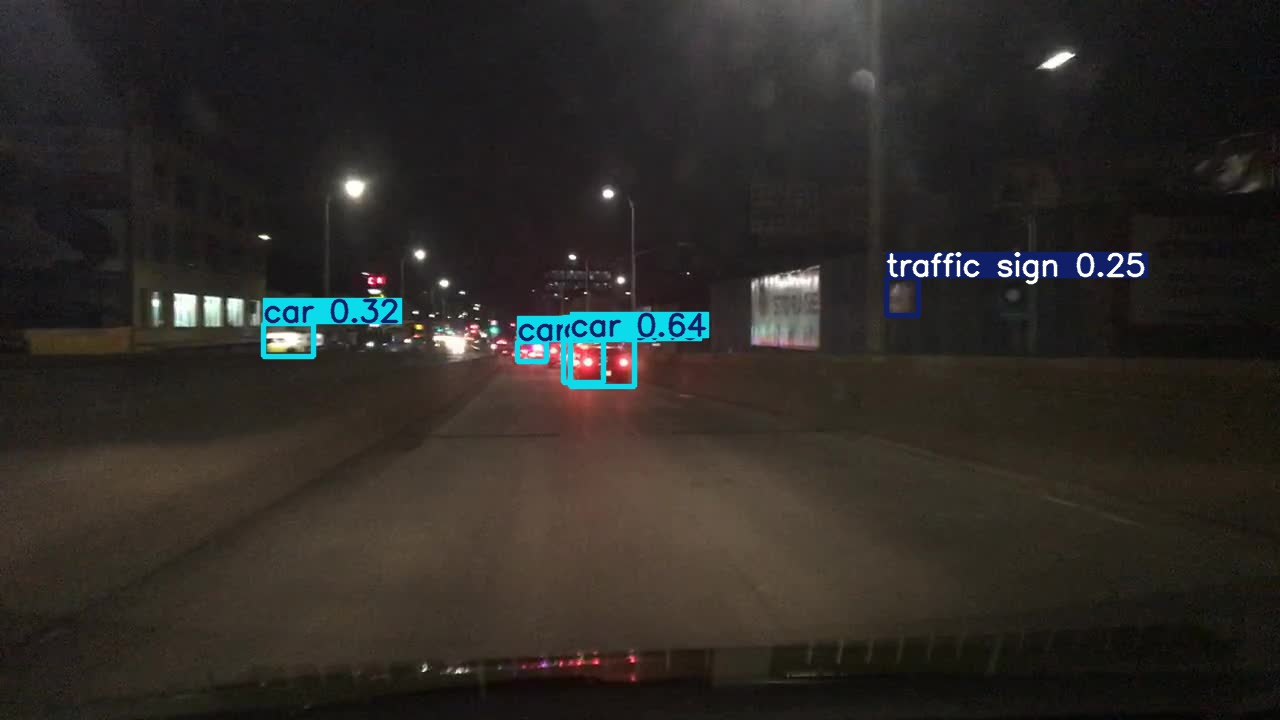

In [17]:
from IPython.display import Image, display

PREDICTED_IMAGE = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/predict/0001542f-5ce3cf52.jpg"

display(Image(filename=PREDICTED_IMAGE))

In [18]:
for result in results:
    print("\nDetected objects:")

    for box in result.boxes:
        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[cls_id]

        print(f"{class_name}: {confidence:.2f}")


Detected objects:
car: 0.64
car: 0.46
car: 0.34
car: 0.32
traffic sign: 0.25


In [19]:
from ultralytics import YOLO
from IPython.display import Image, display

MODEL_PATH = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/FINAL_5CLASS_YOLOv8n_CPU_3epochs/weights/best.pt"

model = YOLO(MODEL_PATH)

results = model.predict(
    source="/content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images",
    imgsz=416,
    conf=0.30,
    device="cpu",
    save=True,
    project="/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs",
    name="final_prediction",
    exist_ok=True
)

print("Prediction completed.")


image 1/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images/b1c66a42-6f7d68ca.jpg: 256x416 22 cars, 60.0ms
image 2/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images/b1c81faa-3df17267.jpg: 256x416 1 traffic sign, 111.8ms
image 3/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images/b1c81faa-c80764c5.jpg: 256x416 2 cars, 3 traffic signs, 93.4ms
image 4/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images/b1c9c847-3bda4659.jpg: 256x416 18 cars, 1 truck, 85.6ms
image 5/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images/b1ca2e5d-84cf9134.jpg: 256x416 2 persons, 5 cars, 117.1ms
image 6/375 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/val/images/b1ca8418-84a133a0.jpg: 256x416 1 car, 1 traffic light, 1 traffic sign, 133.2ms
image 7/375 /content/YOLO/Multi-Class Urban Object De

In [22]:
IMAGE_PATH = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/train/images/0000f77c-6257be58.jpg"

results = model.predict(
    source=IMAGE_PATH,
    imgsz=416,
    conf=0.30,
    device="cpu",
    save=True
)


image 1/1 /content/YOLO/Multi-Class Urban Object Detection Using YOLO/dataset_5class/train/images/0000f77c-6257be58.jpg: 256x416 2 cars, 4 traffic signs, 60.4ms
Speed: 2.4ms preprocess, 60.4ms inference, 0.9ms postprocess per image at shape (1, 3, 256, 416)
Results saved to /content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/predict-2


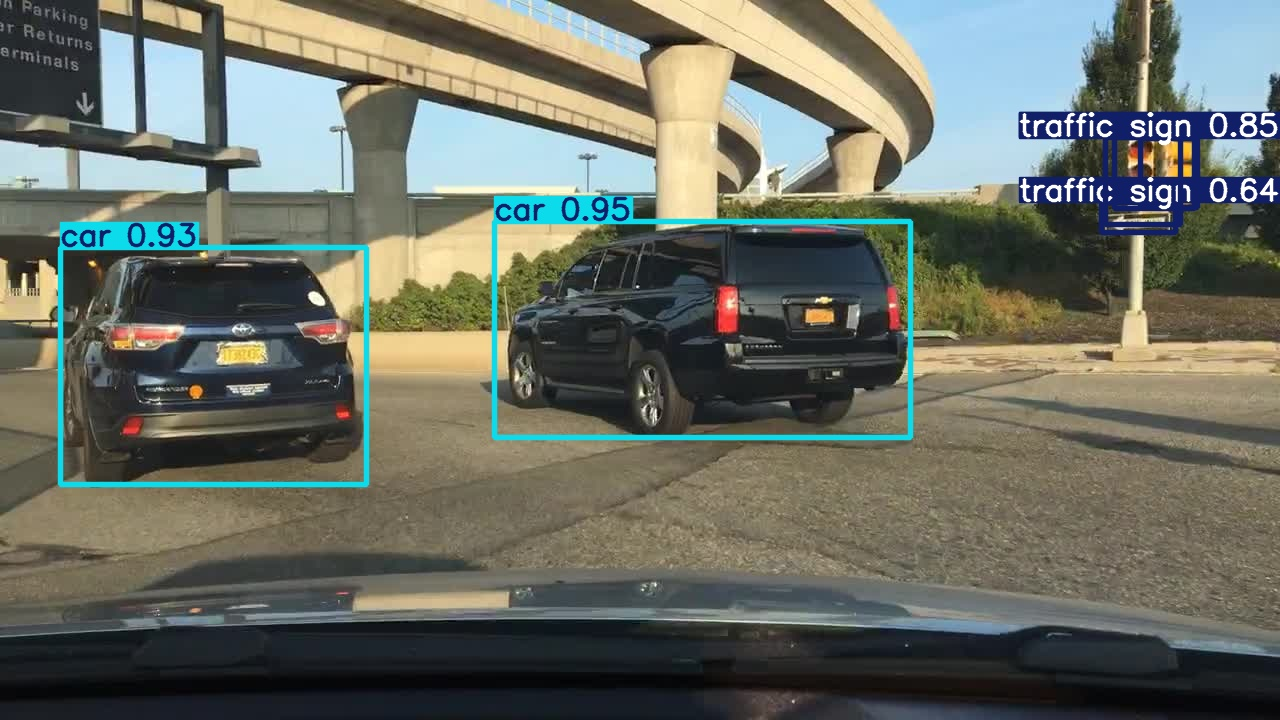

In [24]:
from IPython.display import Image, display

PREDICTED_IMAGE = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/detect/predict-2/0000f77c-6257be58.jpg"

display(Image(filename=PREDICTED_IMAGE))

In [25]:
import os
import shutil

BASE = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"
PROJECT = "/content/urban-object-detection"

os.makedirs(PROJECT, exist_ok=True)

# Copy important files
for file in [
    "train.py",
    "dataset.py",
    "create_small_dataset.py",
    "yolov8n.pt"
]:
    src = os.path.join(BASE, file)
    if os.path.exists(src):
        shutil.copy(src, PROJECT)

# Copy YAML
yaml_src = os.path.join(BASE, "dataset_5class", "data.yaml")
if os.path.exists(yaml_src):
    shutil.copy(yaml_src, os.path.join(PROJECT, "data.yaml"))

print(os.listdir(PROJECT))

['data.yaml', 'train.py', 'dataset.py', 'yolov8n.pt', 'create_small_dataset.py']


In [26]:
BEST_MODEL = "/content/YOLO/Multi-Class Urban Object Detection Using YOLO/runs/FINAL_5CLASS_YOLOv8n_CPU_3epochs/weights/best.pt"

shutil.copy(
    BEST_MODEL,
    "/content/urban-object-detection/best.pt"
)

print("best.pt copied")

best.pt copied


In [27]:
requirements = """ultralytics==8.4.138
opencv-python
matplotlib
Pillow
"""

with open("/content/urban-object-detection/requirements.txt", "w") as f:
    f.write(requirements)

print(requirements)

ultralytics==8.4.138
opencv-python
matplotlib
Pillow



In [28]:
gitignore = """__pycache__/
*.pyc
.ipynb_checkpoints/
runs/
dataset/
dataset_5class/
*.cache
.env
"""

with open("/content/urban-object-detection/.gitignore", "w") as f:
    f.write(gitignore)

In [34]:
%cd "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

/content/YOLO/Multi-Class Urban Object Detection Using YOLO


In [35]:
with open(".gitignore", "w") as f:
    f.write("""dataset/
dataset_5class/
runs/
__pycache__/
*.cache
.ipynb_checkpoints/
""")

In [36]:
import shutil

shutil.copy(
    "runs/FINAL_5CLASS_YOLOv8n_CPU_3epochs/weights/best.pt",
    "best.pt"
)

'best.pt'

In [37]:
!git init
!git branch -M main
!git add .
!git status

Streaming output truncated to the last 5000 lines.
	new file:   dataset/train/labels/03e6369b-c0e99715.txt
	new file:   dataset/train/labels/03e8a5e5-77d7b1d6.txt
	new file:   dataset/train/labels/03e8a5e5-8d8880ef.txt
	new file:   dataset/train/labels/03e94fd1-77f26a75.txt
	new file:   dataset/train/labels/03e9bca4-71d355da.txt
	new file:   dataset/train/labels/03eb2239-87388c18.txt
	new file:   dataset/train/labels/03eb519e-badedd71.txt
	new file:   dataset/train/labels/03eded3c-83924d01.txt
	new file:   dataset/train/labels/03f04c07-201055cc.txt
	new file:   dataset/train/labels/03f05005-89793dee.txt
	new file:   dataset/train/labels/03f05c87-f434a181.txt
	new file:   dataset/train/labels/03f0f5e6-ab7a74ed.txt
	new file:   dataset/train/labels/03f65112-049cca26.txt
	new file:   dataset/train/labels/03f6e688-415b77da.txt
	new file:   dataset/train/labels/03f8899f-569acc1a.txt
	new file:   dataset/train/labels/03f8899f-64fdaa9d.txt
	new file:   dataset/train/labels/03f8899f-c2b15739.t

In [38]:
!git commit -m "Add YOLOv8 multiclass urban object detection"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@c69b3a95130b.(none)')


In [39]:
!git remote add origin https://github.com/prudhvi-raju-jubburu/Multiclassdetection.git

In [40]:
!git push -u origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/prudhvi-raju-jubburu/Multiclassdetection.git'


In [41]:
%cd "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

/content/YOLO/Multi-Class Urban Object Detection Using YOLO


In [42]:
!git init

Reinitialized existing Git repository in /content/YOLO/Multi-Class Urban Object Detection Using YOLO/.git/


In [43]:
!git remote remove origin 2>/dev/null || true
!git remote add origin https://github.com/prudhvi-raju-jubburu/Multiclassdetection.git

In [44]:
!git status

Streaming output truncated to the last 5000 lines.
	new file:   dataset/train/labels/03e6369b-c0e99715.txt
	new file:   dataset/train/labels/03e8a5e5-77d7b1d6.txt
	new file:   dataset/train/labels/03e8a5e5-8d8880ef.txt
	new file:   dataset/train/labels/03e94fd1-77f26a75.txt
	new file:   dataset/train/labels/03e9bca4-71d355da.txt
	new file:   dataset/train/labels/03eb2239-87388c18.txt
	new file:   dataset/train/labels/03eb519e-badedd71.txt
	new file:   dataset/train/labels/03eded3c-83924d01.txt
	new file:   dataset/train/labels/03f04c07-201055cc.txt
	new file:   dataset/train/labels/03f05005-89793dee.txt
	new file:   dataset/train/labels/03f05c87-f434a181.txt
	new file:   dataset/train/labels/03f0f5e6-ab7a74ed.txt
	new file:   dataset/train/labels/03f65112-049cca26.txt
	new file:   dataset/train/labels/03f6e688-415b77da.txt
	new file:   dataset/train/labels/03f8899f-569acc1a.txt
	new file:   dataset/train/labels/03f8899f-64fdaa9d.txt
	new file:   dataset/train/labels/03f8899f-c2b15739.t

In [46]:
!git add .
!git commit -m "Initial commit"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@c69b3a95130b.(none)')


In [47]:
!git config --global user.name "prudhvi-raju-jubburu "
!git config --global user.email "jubburuprudhviraju@gmail.com"

In [48]:
!git config --global user.name
!git config --global user.email

prudhvi-raju-jubburu 
jubburuprudhviraju@gmail.com


In [49]:
%cd "/content/YOLO/Multi-Class Urban Object Detection Using YOLO"

/content/YOLO/Multi-Class Urban Object Detection Using YOLO


In [50]:
!git add .

In [51]:
!git commit -m "Add multiclass YOLOv8 object detection project"

Streaming output truncated to the last 5000 lines.
 create mode 100644 dataset/train/labels/03e20a2f-c96c4ace.txt
 create mode 100644 dataset/train/labels/03e6369b-c0e99715.txt
 create mode 100644 dataset/train/labels/03e8a5e5-77d7b1d6.txt
 create mode 100644 dataset/train/labels/03e8a5e5-8d8880ef.txt
 create mode 100644 dataset/train/labels/03e94fd1-77f26a75.txt
 create mode 100644 dataset/train/labels/03e9bca4-71d355da.txt
 create mode 100644 dataset/train/labels/03eb2239-87388c18.txt
 create mode 100644 dataset/train/labels/03eb519e-badedd71.txt
 create mode 100644 dataset/train/labels/03eded3c-83924d01.txt
 create mode 100644 dataset/train/labels/03f04c07-201055cc.txt
 create mode 100644 dataset/train/labels/03f05005-89793dee.txt
 create mode 100644 dataset/train/labels/03f05c87-f434a181.txt
 create mode 100644 dataset/train/labels/03f0f5e6-ab7a74ed.txt
 create mode 100644 dataset/train/labels/03f65112-049cca26.txt
 create mode 100644 dataset/train/labels/03f6e688-415b77da.txt
 cre

In [52]:
!git branch -M main

In [53]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [54]:
!git remote -v

origin	https://github.com/prudhvi-raju-jubburu/Multiclassdetection.git (fetch)
origin	https://github.com/prudhvi-raju-jubburu/Multiclassdetection.git (push)


In [55]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [56]:
!git status

On branch main
nothing to commit, working tree clean


In [57]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address
